# Extraction

Data extraction. Convert raw ScanImage data into planar, reassembled images.

There are two primary computation steps being performed during this extraction

- Scan-phase correction (fix_phase=True)
- Axial alignment / registration (z_register=True)

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import mbo_utilities as mbo

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,553.09
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 553.09


In [20]:
# on windows, use raw string (r"")
# ..or double backslashes ("D:\\W1_DATA\\...")
# ..or forward slashes ("D:/W1_DATA/...")
raw_path = Path(r"D:\W1_DATA\demos\lbm\2025-03-01_mk301_kbarber")

In [5]:
!tree D:\W1_DATA\demos\lbm\2025-03-01_mk301_kbarber /F /A

Folder PATH listing
Volume serial number is 5C82-1870
D:\W1_DATA\DEMOS\LBM\2025-03-01_MK301_KBARBER
Invalid path - \W1_DATA\DEMOS\LBM\2025-03-01_MK301_KBARBER
No subfolders exist 



## Reading and writing data

`mbo.imread` is a generic reader for data processed via MBO pipelines.

It can read all of the outputs of `mbo.imwrite`, as well as raw ScanImage tiffs.

In [8]:
help(mbo.imread)

Help on function imread in module mbo_utilities.lazy_array:

imread(inputs: 'str | Path | Sequence[str | Path]', **kwargs)
    Lazy load imaging data from supported file types.

    Currently supported file types:
    - .bin: Suite2p binary files (.bin + ops.npy)
    - .tif/.tiff: TIFF files (BigTIFF, OME-TIFF and raw ScanImage TIFFs)
    - .h5: HDF5 files
    - .zarr: Zarr v3

    Parameters
    ----------
    inputs : str, Path, ndarray, MboRawArray, or sequence of str/Path
        Input source. Can be:
        - Path to a file or directory
        - List/tuple of file paths
        - An existing lazy array
    **kwargs
        Extra keyword arguments passed to specific array readers.

    Returns
    -------
    array_like
        One of Suite2pArray, TiffArray, MboRawArray, MBOTiffArray, H5Array,
        or the input ndarray.

    Examples
    -------
    >>> from mbo_utilities import imread
    >>> arr = imread("/data/raw")  # directory with supported files, for full filename



For raw ScanImage tiffs, you can give a filepath to the tiffs or a full filepath to single tiff.

Here, we have all raw files in a directory.

The order in which you chose to split up your frames across tiffs does not matter.

In [9]:
data = mbo.imread(raw_path)
data.shape

(1574, 14, 550, 440)

`imread` returns an array that can be viewed with fastplotlib, and treated like a numpy array.

See [fastplotlib](https://www.fastplotlib.org/user_guide/index.html) documentation for complex visualizations that can be made with some moderate effort.

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
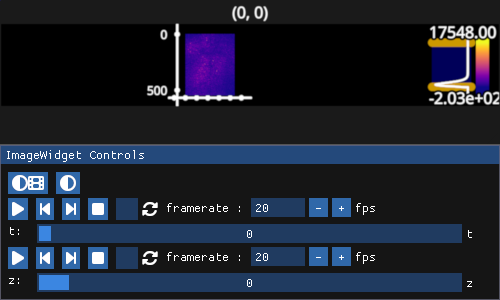

In [16]:
# jupyter-lab only!!!!
import fastplotlib as fpl

iw = fpl.ImageWidget(data)
iw.show()

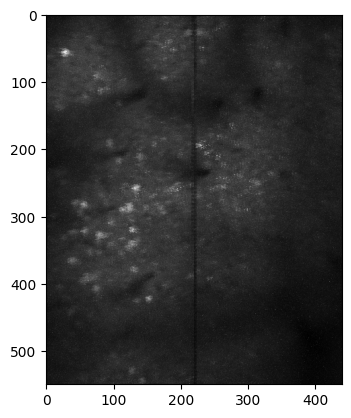

In [10]:
data.roi = None
plt.imshow(data[:,7,:,:].max(axis=0), cmap='gray')

## Scan-Phase Correction

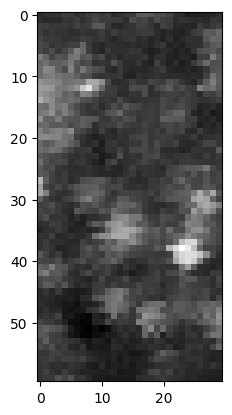

In [59]:
data.fix_phase = False
data.roi = None
plt.imshow(data[:,7,:,:].max(axis=0)[130:190, 250:280], cmap='gray')

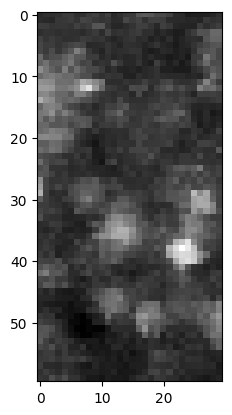

In [60]:
data.fix_phase = True
plt.imshow(data[:,7,:,:].max(axis=0)[130:190, 250:280], cmap='gray')

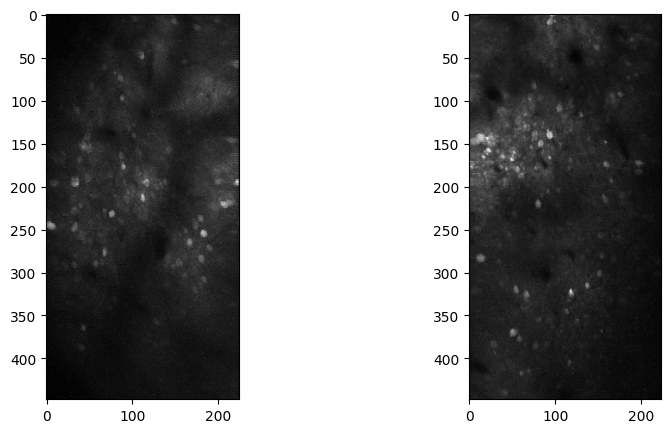

In [49]:
# returns a tuple of all rois
data.roi = 0
mroi1, mroi2 = data[:,7,:,:]

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(mroi1.max(axis=0), cmap='gray')
ax[1].imshow(mroi2.max(axis=0), cmap='gray')

Each lazy array carries metadata from the raw file inside `data.metadata`

In [12]:
data.metadata["frame_rate"], data.metadata["pixel_resolution"], data.metadata["fov"]

(17.06701142272251, array([2., 2.]), (448, 896))

## Data Extraction

- ext: controls which what file-type to save as (.tif, .zarr, .bin etc)
- "tiff" vs "tif" does not matter
- roi=None means fuse each scanimage multi-ROI into a single stitched image
- roi=0 means save each ROI separately, to combine later after segmentation

mbo.imread(
    data_path,
    fix_phase=True,
    use_fft=False
)


In [ ]:
tiff_directory = r"E:\W1_USER_DATA\demo-user\fused-tiff"
mbo.imwrite(
    data,
    tiff_directory,
    register_z=False,  # suite3D registration
    ext=".tiff",
    planes=None, # None = all planes, or list of planes (1-based indexing) [1,2,...]
    roi=None,  # None = fuse mROIs, or index of mROI (0-based indexing) 0,1,...
    metadata={"notes": "No registration, fused mROIs"},
)

Saving plane01_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane02_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane03_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane04_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane05_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

...

Saving plane10_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane11_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane12_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane13_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

Saving plane14_stitched.tiff:   0%|          | 0/31 [00:00<?, ?it/s]

No registration, fused mROIs


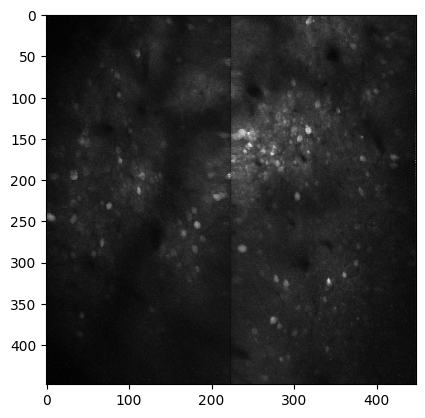

In [14]:
# validation
output_data = mbo.imread(output_directory)
plt.imshow(output_data[:,7,:,:].max(axis=0), cmap='gray')
print(output_data.metadata["notes"])

In [15]:
!tree E:\W1_USER_DATA\demo-user\fused-tiff /F

Folder PATH listing
Volume serial number is 00000269 B832:B598
E:\W1_USER_DATA\DEMO-USER\FUSED-TIFF
    plane01_stitched.tif
    plane02_stitched.tif
    plane03_stitched.tif
    plane04_stitched.tif
    plane05_stitched.tif
    plane06_stitched.tif
    plane07_stitched.tif
    plane08_stitched.tif
    plane09_stitched.tif
    plane10_stitched.tif
    plane11_stitched.tif
    plane12_stitched.tif
    plane13_stitched.tif
    plane14_stitched.tif
    
No subfolders exist 



In [ ]:
output_directory = r"E:\W1_USER_DATA\demo-user\mrois-zarr"
mbo.imwrite(
    data,
    output_directory,
    register_z=True,  # suite3D registration
    ext=".zarr",
    planes=[1, 7, 14], # None = all planes, or list of planes (1-based indexing) [1,2,...]
    roi=0, # None = fuse-mROIs, 0 is all rois separately, or list of rois [0,1,2,...]
    metadata={"notes": "No registration, selected planes 1, 7, 14, separate mROIs, with registration using suite3D"},
)

No s3d-job detected, preprocessing data.
Running Suite3D job...
    Loaded file into shared memory in 0.59 sec
    Workers completed in 1.34 sec
    Total time: 1.92 sec
Suite 3D init pass done in 27.3 seconds.
Preprocessed data saved to E:\W1_USER_DATA\demo-user\mrois-zarr\s3d-preprocessed
Registered z-planes, results saved to E:\W1_USER_DATA\demo-user\mrois-zarr\s3d-preprocessed.


Saving plane01_roi1.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane07_roi1.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane14_roi1.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane01_roi2.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane07_roi2.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

Saving plane14_roi2.zarr:   0%|          | 0/5 [00:00<?, ?it/s]

In [29]:
output_data = mbo.imread(output_directory)
type(output_data), output_data.metadata["notes"]

(mbo_utilities.array_types.ZarrArray,
 'No registration, selected planes 1, 7, 14, separate mROIs, with registration using suite3D')

In [31]:
!dir E:\W1_USER_DATA\demo-user\mrois-zarr

 Volume in drive E has no label.
 Volume Serial Number is B832-B598

 Directory of E:\W1_USER_DATA\demo-user\mrois-zarr

10/01/2025  03:18 PM    <DIR>          .
10/01/2025  02:26 PM    <DIR>          ..
10/01/2025  03:06 PM    <DIR>          plane01_roi1.zarr
10/01/2025  03:07 PM    <DIR>          plane01_roi2.zarr
10/01/2025  03:06 PM    <DIR>          plane07_roi1.zarr
10/01/2025  03:07 PM    <DIR>          plane07_roi2.zarr
10/01/2025  03:06 PM    <DIR>          plane14_roi1.zarr
10/01/2025  03:07 PM    <DIR>          plane14_roi2.zarr
10/01/2025  03:18 PM    <DIR>          s3d-preprocessed
               0 File(s)              0 bytes
               9 Dir(s)  2,832,070,037,504 bytes free


In [ ]:
import numpy as np
volume = np.load("E:/W1_USER_DATA/demo-user/mrois-zarr/s3d-preprocessed/summary/init_mov.npy")
# volume shape: (z, t, y, x)
max_vol = volume.max(axis=1) # max projection along time axis
print(f"z: {max_vol.shape[0]}, y: {max_vol.shape[1]}, x: {max_vol.shape[2]}")

z: 14, y: 562, x: 457


In [ ]:
# helpful on VS Code, which doesnt yet work with fastplotlib

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Z, H, W = max_vol.shape

fig, ax = plt.subplots()
im = ax.imshow(max_vol[0], cmap="gray", animated=True)

def update(frame):
    im.set_array(max_vol[frame])
    return [im]

ani = FuncAnimation(fig, update, frames=Z, interval=50, blit=True)
plt.close(fig)
from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
output_directory = r"E:\W1_USER_DATA\demo-user\mrois-zarr-zreg"
mbo.imwrite(
    data,
    output_directory,
    register_z=True,  # suite3D registration
    ext=".zarr",
    planes=None, # None = all planes, or list of planes (1-based indexing) [1,2,...]
    roi=0, # None = fuse-mROIs, 0 is all rois separately, or list of rois [0,1,2,...]
    metadata={"notes": "All z-planes, separate mROIs, with registration using suite3D"},
)

No s3d-job detected, preprocessing data.
Running Suite3D job...
    Loaded file into shared memory in 0.38 sec
    Workers completed in 1.29 sec
    Total time: 1.66 sec
Suite 3D init pass done in 22.2 seconds.
Preprocessed data saved to E:\W1_USER_DATA\demo-user\mrois-zarr-zreg\s3d-preprocessed
Registered z-planes, results saved to E:\W1_USER_DATA\demo-user\mrois-zarr-zreg\s3d-preprocessed.


Saving plane01_roi1.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane02_roi1.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane03_roi1.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane04_roi1.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

...

Saving plane10_roi2.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane11_roi2.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane12_roi2.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane13_roi2.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

Saving plane14_roi2.zarr:   0%|          | 0/16 [00:00<?, ?it/s]

In [62]:
data_zarr = mbo.imread(output_directory)
print(f" Type of array: {type(data_zarr)} \n\n Shape: {data_zarr.shape} \n\n Notes from metadata: {data_zarr.metadata["notes"]}")

 Type of array: <class 'mbo_utilities.array_types.ZarrArray'> 

 Shape: (1618, 28, 560, 231) 

 Notes from metadata: All z-planes, separate mROIs, with registration using suite3D


## Metadata

There is a `metadata.html` file saved alongside the extracted output files. 

All metadata is copied over during each processing step.

In [66]:
data.metadata["fov"]

(448, 896)

In [69]:
zarr_array = mbo.imread(r"E:\W1_USER_DATA\demo-user\mrois-zarr-zreg")
zarr_array.shape, type(zarr_array)

((1618, 28, 560, 231), mbo_utilities.array_types.ZarrArray)

In [74]:
tiff_array = mbo.imread(r"E:\W1_USER_DATA\demo-user\fused-tiff")
tiff_array.shape, tiff_array.metadata["notes"]

((1618, 14, 448, 224), 'No registration, fused mROIs')

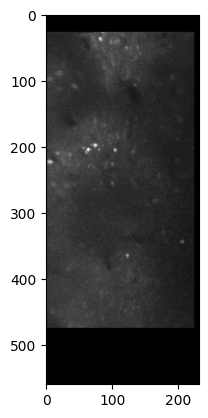

In [71]:
plt.imshow(zarr_array[:,7,:,:].max(axis=0), cmap='gray')

'No registration, fused mROIs'

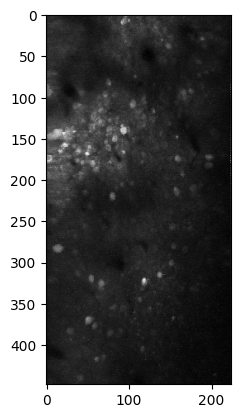

In [73]:
plt.imshow(tiff_array[:,7,:,:].max(axis=0), cmap='gray')
tiff_array.metadata["notes"]

# Next notebook: [2_extraction](./2_extraction.ipynb)